# Persistence & Checkpoints — LangGraph

**Concepts covered:**
1. `MemorySaver` checkpointer — saves state at every superstep (checkpoint)
2. `get_state(config)` — fetch final state for a thread
3. `get_state_history(config)` — fetch all intermediate + final states
4. Thread isolation — multiple executions stored independently by `thread_id`
5. **Time travel** — replay from any past checkpoint; fork with updated state

**Workflow:** START → generate_joke → generate_explanation → END

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.llms.fake import FakeListLLM
from typing import TypedDict, Optional
from dotenv import load_dotenv

load_dotenv()

C:\Users\Deepika Yadav\AppData\Local\Temp\ipykernel_16056\696374299.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.llms.fake import FakeListLLM


True

## Step 1 — State

In [2]:
class JokeState(TypedDict):
    topic: str
    joke: Optional[str]
    explanation: Optional[str]

## Step 2 — Mock LLMs

4 responses each: pizza run, pasta run, time-travel replay, samosa fork.

In [3]:
joke_llm = FakeListLLM(responses=[
    'Why did the pizza go to the doctor? Because it was feeling a little cheesy!',
    'Why did the pasta go to school? Because it wanted to get a little saucy!',
    'Why did the slice of pizza go to the party? Because it wanted to get saucy!',  # time travel
    'Why did the samosa cross the road? To get to the crispy side!',               # state update fork
])

explanation_llm = FakeListLLM(responses=[
    "'Cheesy' is a pun: both 'containing cheese' and 'of poor taste'.",
    "'Saucy' means both 'covered in sauce' and 'cheeky/bold' — a classic double meaning.",
    "Same wordplay as before: 'saucy' works on two levels.",  # time travel
    "'Crispy' plays on the samosa's texture and making a 'crisp' (decisive) choice.",  # fork
])

## Step 3 — Nodes

In [4]:
def generate_joke(state: JokeState) -> dict:
    prompt = f"Generate a short funny joke on the topic: {state['topic']}"
    return {'joke': joke_llm.invoke(prompt)}


def generate_explanation(state: JokeState) -> dict:
    prompt = f"Explain briefly why this joke is funny: {state['joke']}"
    return {'explanation': explanation_llm.invoke(prompt)}

## Step 4 — Build Graph with MemorySaver

In [5]:
checkpointer = MemorySaver()

graph = StateGraph(JokeState)
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

workflow = graph.compile(checkpointer=checkpointer)
print('Graph compiled with MemorySaver.')

Graph compiled with MemorySaver.


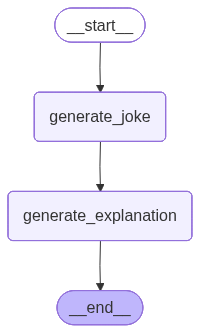

In [6]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

---
## Part A — Execute Thread 1 (topic: pizza)

In [7]:
config_1 = {'configurable': {'thread_id': '1'}}

result_1 = workflow.invoke(
    {'topic': 'pizza', 'joke': None, 'explanation': None},
    config=config_1
)
print('Topic      :', result_1['topic'])
print('Joke       :', result_1['joke'])
print('Explanation:', result_1['explanation'])

Topic      : pizza
Joke       : Why did the pizza go to the doctor? Because it was feeling a little cheesy!
Explanation: 'Cheesy' is a pun: both 'containing cheese' and 'of poor taste'.


### `get_state` — fetch current (final) state for a thread

In [8]:
snapshot = workflow.get_state(config_1)
print('Values :', snapshot.values)
print('Next   :', snapshot.next, '  ← empty means workflow is done')

Values : {'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little cheesy!', 'explanation': "'Cheesy' is a pun: both 'containing cheese' and 'of poor taste'."}
Next   : ()   ← empty means workflow is done


### `get_state_history` — all intermediate + final states

One checkpoint is saved per superstep. For this 2-node graph → 4 checkpoints total:
- Before any node (empty)
- After START injects initial input
- After `generate_joke`
- After `generate_explanation`

In [9]:
history_1 = list(workflow.get_state_history(config_1))  # newest first
print(f'Total checkpoints: {len(history_1)}\n')

for i, snap in enumerate(reversed(history_1)):  # show oldest → newest
    print(f'--- Checkpoint {i+1} ---')
    print('  topic      :', snap.values.get('topic'))
    print('  joke       :', snap.values.get('joke'))
    print('  explanation:', snap.values.get('explanation'))
    print('  next       :', snap.next)
    print()

Total checkpoints: 4

--- Checkpoint 1 ---
  topic      : None
  joke       : None
  explanation: None
  next       : ('__start__',)

--- Checkpoint 2 ---
  topic      : pizza
  joke       : None
  explanation: None
  next       : ('generate_joke',)

--- Checkpoint 3 ---
  topic      : pizza
  joke       : Why did the pizza go to the doctor? Because it was feeling a little cheesy!
  explanation: None
  next       : ('generate_explanation',)

--- Checkpoint 4 ---
  topic      : pizza
  joke       : Why did the pizza go to the doctor? Because it was feeling a little cheesy!
  explanation: 'Cheesy' is a pun: both 'containing cheese' and 'of poor taste'.
  next       : ()



---
## Part B — Execute Thread 2 (topic: pasta)

In [10]:
config_2 = {'configurable': {'thread_id': '2'}}

result_2 = workflow.invoke(
    {'topic': 'pasta', 'joke': None, 'explanation': None},
    config=config_2
)
print('Topic      :', result_2['topic'])
print('Joke       :', result_2['joke'])
print('Explanation:', result_2['explanation'])

Topic      : pasta
Joke       : Why did the pasta go to school? Because it wanted to get a little saucy!
Explanation: 'Saucy' means both 'covered in sauce' and 'cheeky/bold' — a classic double meaning.


### Thread isolation — different thread_ids keep separate state histories

In [11]:
print('Thread 1 topic (pizza):', workflow.get_state(config_1).values['topic'])
print('Thread 2 topic (pasta):', workflow.get_state(config_2).values['topic'])

Thread 1 topic (pizza): pizza
Thread 2 topic (pasta): pasta


---
## Part C — Time Travel

### Step 1: Find the checkpoint where joke has NOT yet been generated

In [12]:
history_1 = list(workflow.get_state_history(config_1))  # refresh

# Find checkpoint where next node is 'generate_joke'
target = None
for snap in history_1:
    if 'generate_joke' in snap.next:
        target = snap
        break

print('Target checkpoint state :', target.values)
print('Target checkpoint next  :', target.next)
print('Checkpoint ID           :', target.config['configurable']['checkpoint_id'])

Target checkpoint state : {'topic': 'pizza', 'joke': None, 'explanation': None}
Target checkpoint next  : ('generate_joke',)
Checkpoint ID           : 1f1656af-f2f7-6bb2-8000-d4c8b35ab3a8


### Step 2: Replay — re-run from that checkpoint

Pass `None` as state (no new input) + the checkpoint's own config. LangGraph resumes from that exact point.

In [13]:
replayed = workflow.invoke(None, config=target.config)
print('Topic      :', replayed['topic'])
print('Joke       :', replayed['joke'],      '← different from original (LLMs are probabilistic)')
print('Explanation:', replayed['explanation'])

Topic      : pizza
Joke       : Why did the slice of pizza go to the party? Because it wanted to get saucy! ← different from original (LLMs are probabilistic)
Explanation: Same wordplay as before: 'saucy' works on two levels.


### Step 3: Fork — update state at that checkpoint (change topic) then replay

In [14]:
# update_state creates a new fork and returns the new checkpoint's config
forked_config = workflow.update_state(target.config, {'topic': 'samosa'})
print('Forked config:', forked_config)

Forked config: {'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1656af-f3a8-69d3-8001-f5e35b9a528d'}}


In [15]:
samosa_result = workflow.invoke(None, config=forked_config)
print('Topic      :', samosa_result['topic'])
print('Joke       :', samosa_result['joke'])
print('Explanation:', samosa_result['explanation'])

Topic      : samosa
Joke       : Why did the samosa cross the road? To get to the crispy side!
Explanation: 'Crispy' plays on the samosa's texture and making a 'crisp' (decisive) choice.


### Final checkpoint count — history grows with each time-travel branch

In [16]:
final_history = list(workflow.get_state_history(config_1))
print(f'Checkpoints in thread 1: {len(final_history)}')
print()
for i, snap in enumerate(reversed(final_history)):
    print(f'[{i+1}] topic={snap.values.get("topic")!r:10}  '
          f'joke_set={snap.values.get("joke") is not None}  '
          f'expl_set={snap.values.get("explanation") is not None}  '
          f'next={list(snap.next)}')

Checkpoints in thread 1: 10

[1] topic=None        joke_set=False  expl_set=False  next=['__start__']
[2] topic='pizza'     joke_set=False  expl_set=False  next=['generate_joke']
[3] topic='pizza'     joke_set=True  expl_set=False  next=['generate_explanation']
[4] topic='pizza'     joke_set=True  expl_set=True  next=[]
[5] topic='pizza'     joke_set=False  expl_set=False  next=['generate_joke']
[6] topic='pizza'     joke_set=True  expl_set=False  next=['generate_explanation']
[7] topic='pizza'     joke_set=True  expl_set=True  next=[]
[8] topic='samosa'    joke_set=False  expl_set=False  next=['generate_joke']
[9] topic='samosa'    joke_set=True  expl_set=False  next=['generate_explanation']
[10] topic='samosa'    joke_set=True  expl_set=True  next=[]
